# EDA — Early Prediction of Multistate MD Behavior

Exploratory data analysis for labeled trajectory dataset. Update `CSV_PATH` in config and run all cells.

---

## 1 · Configuration & Setup

Edit `CSV_PATH` to point at your labeled data.

In [15]:
from pathlib import Path

# ── EDIT THESE ──────────────────────────────────────────────────────────────

# Path to labeled CSV (relative to this notebook, or absolute)
CSV_PATH = Path("../data/processed/data_processed_v3_base_dataset_deduped.csv")

# Optional: path to a second CSV to compare against (set to None to skip)
# e.g. after re-labeling with different thresholds, or after adding new trajectories
COMPARE_CSV_PATH = Path("../data/processed/data_bootstrapped_v3_bootstrap_dataset.csv")
# COMPARE_CSV_PATH = Path("data/processed/features_labeled_train_v2.csv")

# Dataset version label (used in plot titles and saved filenames)
VERSION_LABEL = "v3_deduped"
COMPARE_VERSION_LABEL = "bootstrapped_v3"   # only used if COMPARE_CSV_PATH is set

# Where to save figures (will be created if it doesn't exist)
FIG_DIR = Path(f"eda_outputs/{VERSION_LABEL}")

# Label thresholds used during data generation — used to draw reference lines
DOMINANT_THRESH = 0.75
SILHOUETTE_THRESH = 0.50

# ── CONSTANTS (don't need to change these) ───────────────────────────────────
LABEL_COL  = "label"
FEAT_COLS  = ["rmsd_mean", "rmsd_std", "rmsd_max", "rg_mean", "rg_std",
              "tm3_tm6_mean", "tm3_tm6_std"]
C_MULTI    = "#e05252"
C_SINGLE   = "#5b8dee"
C_WARN     = "#c07840"
PALETTE    = {"multi_state": C_MULTI, "single_state": C_SINGLE}

FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"Config OK. Figures will be saved to: {FIG_DIR.resolve()}")

Config OK. Figures will be saved to: \\wsl.localhost\Ubuntu\home\persav\git\cs229-md-prediction\notebooks\eda_outputs\v3_deduped


In [16]:
import warnings
import textwrap
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
np.random.seed(42)

# Updated style with larger, more readable fonts
plt.rcParams.update({
    "figure.facecolor": "#f5f5f5", "axes.facecolor": "#ffffff",
    "axes.edgecolor": "#333333",   "axes.labelcolor": "#000000",
    "axes.titlecolor": "#000000",  "xtick.color": "#333333",
    "ytick.color": "#333333",      "text.color": "#000000",
    "grid.color": "#dddddd",       "grid.linewidth": 0.8,
    "font.family": "sans-serif",   "font.size": 11,
    "axes.titlesize": 13,          "axes.titleweight": "bold",
    "axes.labelsize": 11,          "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,         "legend.title_fontsize": 11,
    "legend.facecolor": "#ffffff", "legend.edgecolor": "#cccccc",
    "savefig.facecolor": "#ffffff","savefig.bbox": "tight",
    "savefig.dpi": 200,            "figure.dpi": 100,
})

print("Libraries loaded.")

Libraries loaded.


## 2 · Load & Validate Data

In [17]:
def load_and_validate(path):
    """Load CSV, check required columns, print a quick summary."""
    path = Path(path)
    assert path.exists(), f"File not found: {path.resolve()}"
    df = pd.read_csv(path)
    
    required = {LABEL_COL, "receptor", "rep", "rmsd_mean", "rmsd_std",
                "dominant_cluster_frac", "silhouette"}
    missing = required - set(df.columns)
    assert not missing, f"Missing columns: {missing}"
    
    print(f"Loaded: {path.name}")
    print(f"  Shape:           {df.shape}")
    print(f"  Label counts:    {df[LABEL_COL].value_counts().to_dict()}")
    print(f"  Unique proteins: {df['receptor'].nunique()}")
    if "n_frames_total" in df.columns:
        print(f"  Frames (median): {df['n_frames_total'].median():.0f}")
    
    # NaN summary for feature columns
    nan_cols = {c: df[c].isna().sum() for c in FEAT_COLS if c in df.columns and df[c].isna().sum() > 0}
    if nan_cols:
        print(f"  NaN features:    {nan_cols}")
    
    return df

df = load_and_validate(CSV_PATH)

Loaded: data_processed_v3_base_dataset_deduped.csv
  Shape:           (247, 22)
  Label counts:    {'single_state': 176, 'multi_state': 71}
  Unique proteins: 144
  Frames (median): 2500
  NaN features:    {'rg_mean': 3, 'rg_std': 3, 'tm3_tm6_mean': 32, 'tm3_tm6_std': 32}


In [20]:
def run_qc(df, label=""):
    """Run data quality checks and print flagged issues."""
    flags = []
    
    # Duplicate features (likely shared trajectory files)
    dup_cols = ["rmsd_mean", "rmsd_std", "rg_mean"]
    dups = df[df.duplicated(dup_cols, keep=False)]
    if not dups.empty:
        flags.append(("WARN", f"{len(dups)} rows with identical (rmsd_mean, rmsd_std, rg_mean) "
                      f"— likely shared trajectory files: {dups['receptor'].tolist()}"))

    # Explicit traj file duplicates
    if "traj_file" in df.columns:
        traj_dups = df[df.duplicated("traj_file", keep=False)]
        for traj, grp in traj_dups.groupby("traj_file"):
            flags.append(("WARN", f"Same traj file for {list(grp['receptor'])}: {traj}"))
    
    # Class imbalance
    vc = df[LABEL_COL].value_counts()
    ratio = vc.max() / max(vc.min(), 1)
    level = "WARN" if ratio > 3 else "INFO"
    flags.append((level, f"Class imbalance ratio: {ratio:.1f}:1  →  {dict(vc)}"))
    
    # NaN features
    for col in FEAT_COLS:
        if col in df.columns:
            n = df[col].isna().sum()
            if n > 0:
                flags.append(("WARN", f"{n} NaN values in '{col}'"))
    
    # Short trajectories
    if "n_frames_total" in df.columns:
        for _, r in df[df["n_frames_total"] < 500].iterrows():
            flags.append(("WARN", f"Short trajectory: {r['receptor']} rep{r['rep']} = {r['n_frames_total']} frames"))
    
    # Within-protein label inconsistency across reps
    prot = df["receptor"].str.extract(r"^([^~]+~[^~]+)")[0]
    for p, grp in df.groupby(prot):
        if grp[LABEL_COL].nunique() > 1:
            details = list(grp[["rep", LABEL_COL]].itertuples(index=False, name=None))
            flags.append(("INFO", f"Mixed labels across replicates for {p}: {details}"))
    
    header = f"QC FLAGS — {label}" if label else "QC FLAGS"
    print(f"\n{'─'*60}")
    print(f"  {header}")
    print(f"{'─'*60}")
    for level, msg in flags:
        icon = "WARNING:" if level == "WARN" else "INFO:"
        wrapped = textwrap.fill(msg, width=70, subsequent_indent="      ")
        print(f"  {icon} {wrapped}")
    if not flags:
        print("  No issues found.")
    
    return flags

flags = run_qc(df, VERSION_LABEL)


────────────────────────────────────────────────────────────
  QC FLAGS — v3_deduped
────────────────────────────────────────────────────────────
      trajectory files: ['Beta-1_adrenergic_receptor~3ZPR_B',
      'Beta-1_adrenergic_receptor~3ZPR_B',
      'Type-1_angiotensin_II_receptor~4ZUD_A',
      'Type-1_angiotensin_II_receptor~4ZUD_A', 'unknown~3P2D',
      'unknown~3P2D']
  INFO: Class imbalance ratio: 2.5:1  →  {'single_state': 176, 'multi_state':
      71}
  INFO: Mixed labels across replicates for
      5-hydroxytryptamine_receptor_2B~4IB4_A: [(1, 'single_state'),
      (1, 'multi_state')]
  INFO: Mixed labels across replicates for ADRB2~3NYA_A: [(2, 'single_state'),
      (3, 'multi_state')]
  INFO: Mixed labels across replicates for Adenosine_receptor_A2a~2YDO_A: [(1,
      'multi_state'), (1, 'single_state')]
  INFO: Mixed labels across replicates for Adenosine_receptor_A2a~3UZA_A: [(1,
      'single_state'), (2, 'multi_state')]
  INFO: Mixed labels across replicates for

## 3 · Dataset Overview & Class Balance

Class balance, trajectory lengths, replicates per protein.

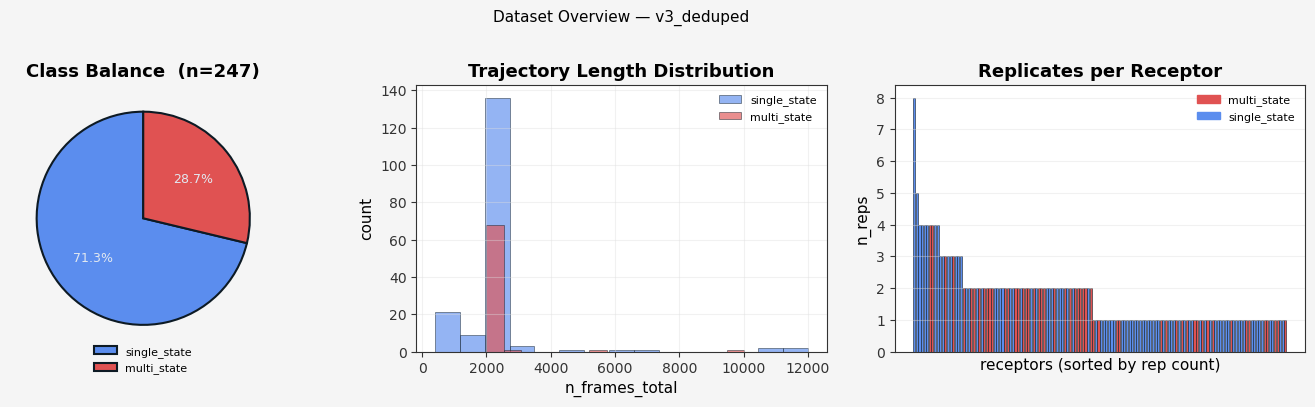

Saved: eda_outputs\v3_deduped/fig_overview.png


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f"Dataset Overview — {VERSION_LABEL}", fontsize=11, y=1.01)

# 3a. Class balance
ax = axes[0]
vc = df[LABEL_COL].value_counts()
colors = [PALETTE.get(k, "#888") for k in vc.index]
ax.pie(vc.values, labels=None, colors=colors, autopct="%1.1f%%",
       startangle=90, wedgeprops={"linewidth": 1.5, "edgecolor": "#0d1a24"},
       textprops={"color": "#e2e8f0", "fontsize": 9})
ax.legend(vc.index, loc="lower center", fontsize=8, framealpha=0,
          bbox_to_anchor=(0.5, -0.12))
ax.set_title(f"Class Balance  (n={len(df)})")

# Imbalance warning annotation
ratio = vc.max() / vc.min()

# 3b. Frame count distribution
ax = axes[1]
if "n_frames_total" in df.columns:
    for lbl in ["single_state", "multi_state"]:
        vals = df[df[LABEL_COL] == lbl]["n_frames_total"].dropna()
        ax.hist(vals, bins=15, color=PALETTE[lbl], alpha=0.65,
                label=lbl, edgecolor="#0d1a24", linewidth=0.5)
    ax.set_xlabel("n_frames_total")
    ax.set_ylabel("count")
    ax.set_title("Trajectory Length Distribution")
    ax.legend(fontsize=8, framealpha=0)
    ax.grid(True, alpha=0.4)

# 3c. Reps per protein
ax = axes[2]
reps_per = df.groupby("receptor")["rep"].count().sort_values(ascending=False)
bar_colors = [PALETTE.get(df[df["receptor"]==r][LABEL_COL].mode()[0], "#888")
              for r in reps_per.index]
ax.bar(range(len(reps_per)), reps_per.values, color=bar_colors,
       edgecolor="#0d1a24", linewidth=0.4)
ax.set_xticks([])
ax.set_xlabel("receptors (sorted by rep count)")
ax.set_ylabel("n_reps")
ax.set_title("Replicates per Receptor")
ax.grid(True, alpha=0.4, axis="y")
ax.legend(handles=[
    mpatches.Patch(color=C_MULTI, label="multi_state"),
    mpatches.Patch(color=C_SINGLE, label="single_state"),
], fontsize=8, framealpha=0)

plt.tight_layout()
fig.savefig(FIG_DIR / "fig_overview.png")
plt.show()
print(f"Saved: {FIG_DIR}/fig_overview.png")

## 4 · Label Generation Diagnostics

TICA + k-means labeling thresholds. `dominant_cluster_frac` and `silhouette` are label artifacts, not model inputs.

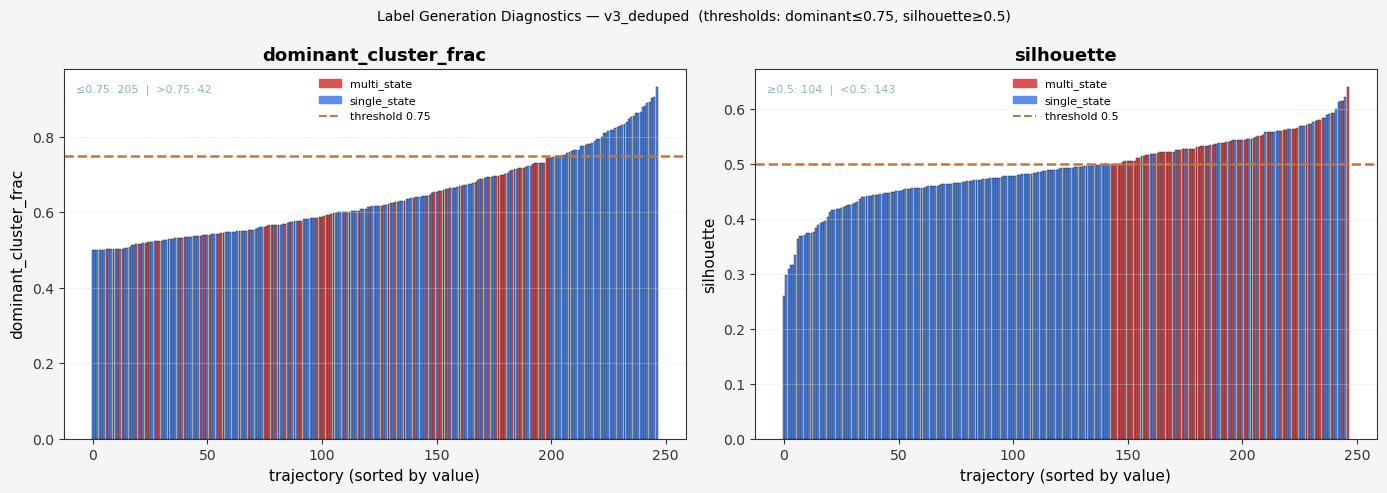

Saved: eda_outputs\v3_deduped/fig_label_diagnostics.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Label Generation Diagnostics — {VERSION_LABEL}  "
             f"(thresholds: dominant≤{DOMINANT_THRESH}, silhouette≥{SILHOUETTE_THRESH})",
             fontsize=10)

for ax, col, thresh, direction in [
    (axes[0], "dominant_cluster_frac", DOMINANT_THRESH, "le"),
    (axes[1], "silhouette",            SILHOUETTE_THRESH, "ge"),
]:
    sorted_df = df.dropna(subset=[col]).sort_values(col).reset_index(drop=True)
    colors = [PALETTE.get(l, "#888") for l in sorted_df[LABEL_COL]]
    ax.bar(range(len(sorted_df)), sorted_df[col],
           color=colors, edgecolor="#0d1a24", linewidth=0.3, width=0.85)
    ax.axhline(thresh, color=C_WARN, linestyle="--", lw=1.8,
               label=f"threshold = {thresh}")
    ax.set_title(col)
    ax.set_xlabel("trajectory (sorted by value)")
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3, axis="y")
    
    # Count how many are on each side of the threshold
    if direction == "le":
        n_below = (sorted_df[col] <= thresh).sum()
        n_above = (sorted_df[col] > thresh).sum()
        ax.text(0.02, 0.96, f"≤{thresh}: {n_below}  |  >{thresh}: {n_above}",
                transform=ax.transAxes, fontsize=8, color="#8ab4c8", va="top")
    else:
        n_above = (sorted_df[col] >= thresh).sum()
        n_below = (sorted_df[col] < thresh).sum()
        ax.text(0.02, 0.96, f"≥{thresh}: {n_above}  |  <{thresh}: {n_below}",
                transform=ax.transAxes, fontsize=8, color="#8ab4c8", va="top")
    
    ax.legend(handles=[
        mpatches.Patch(color=C_MULTI, label="multi_state"),
        mpatches.Patch(color=C_SINGLE, label="single_state"),
        Line2D([0],[0], color=C_WARN, linestyle="--", lw=1.5, label=f"threshold {thresh}"),
    ], fontsize=8, framealpha=0)

plt.tight_layout()
fig.savefig(FIG_DIR / "fig_label_diagnostics.png")
plt.show()
print(f"Saved: {FIG_DIR}/fig_label_diagnostics.png")

## 5 · Feature Distributions by Label

Early-segment features (first 20% of frames). Box plots show IQR, median line, ◆ = mean.

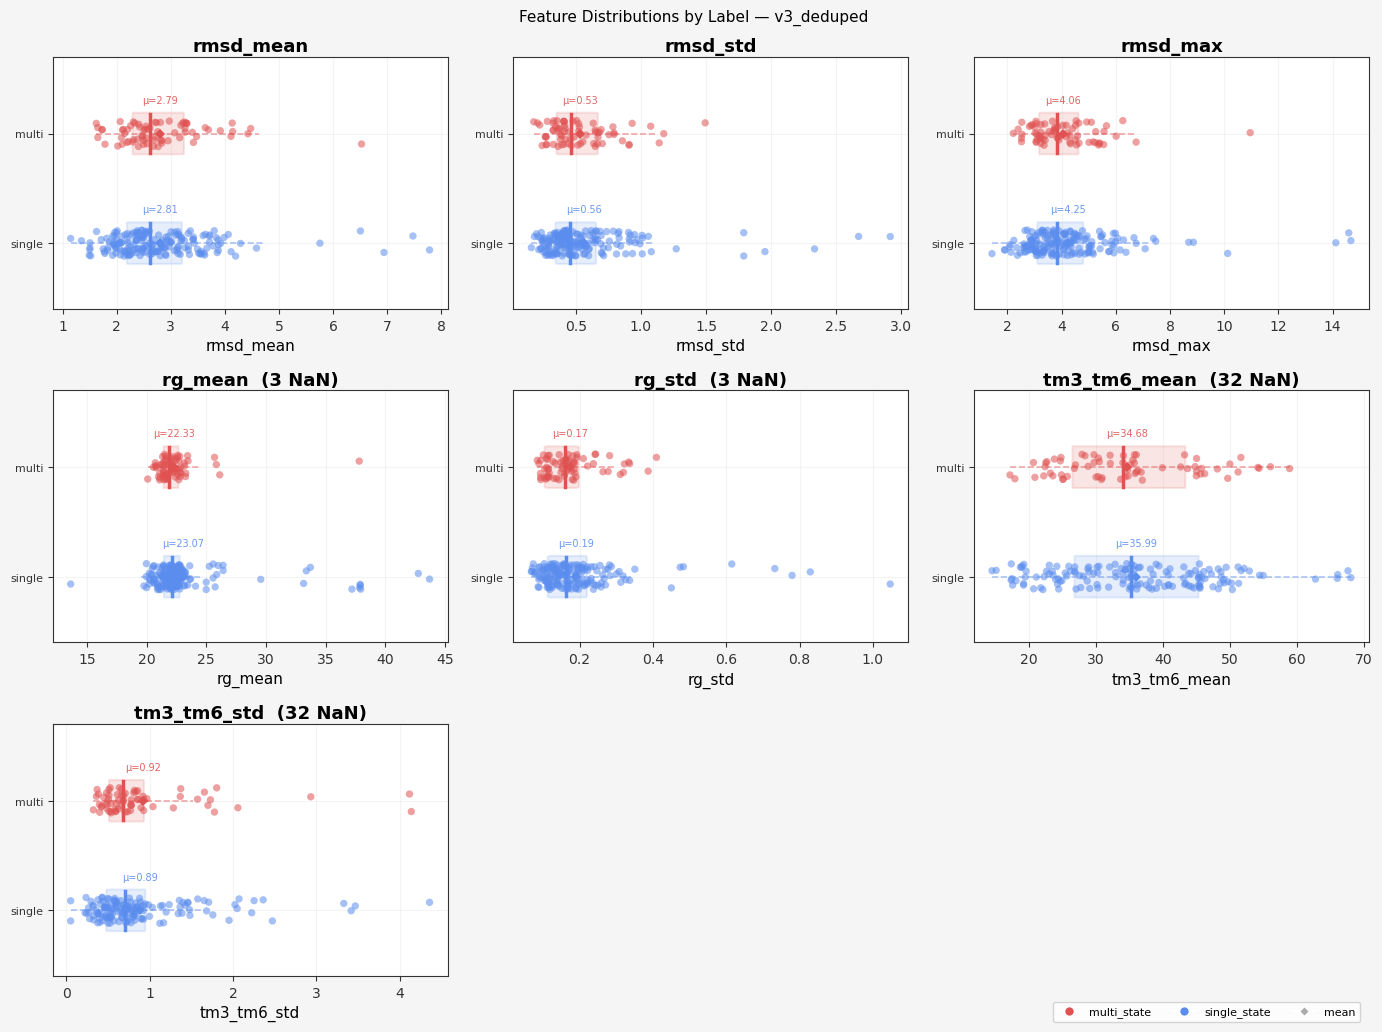

Saved: eda_outputs\v3_deduped/fig_features.png


In [23]:
available_feats = [c for c in FEAT_COLS if c in df.columns and df[c].notna().sum() > 2]
ncols = 3
nrows = (len(available_feats) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.5))
axes = np.array(axes).flatten()
fig.suptitle(f"Feature Distributions by Label — {VERSION_LABEL}", fontsize=11)

for i, col in enumerate(available_feats):
    ax = axes[i]
    ax.grid(True, alpha=0.3)

    for y_pos, lbl in enumerate(["single_state", "multi_state"]):
        vals = df[df[LABEL_COL] == lbl][col].dropna().values
        if len(vals) == 0:
            continue
        color = PALETTE[lbl]
        
        # Jittered strip
        jitter = np.random.uniform(-0.12, 0.12, len(vals))
        ax.scatter(vals, np.full(len(vals), y_pos) + jitter,
                   color=color, alpha=0.55, s=28, zorder=3, edgecolors="none")
        
        # Box summary
        q1, med, q3 = np.percentile(vals, [25, 50, 75])
        iqr = q3 - q1
        lo_w = max(vals.min(), q1 - 1.5 * iqr)
        hi_w = min(vals.max(), q3 + 1.5 * iqr)
        ax.plot([lo_w, hi_w], [y_pos, y_pos], color=color, lw=1.2,
                alpha=0.5, zorder=2, linestyle="--")
        ax.add_patch(mpatches.FancyBboxPatch(
            (q1, y_pos - 0.18), q3 - q1, 0.36,
            boxstyle="round,pad=0.01", linewidth=1.5,
            edgecolor=color, facecolor=color, alpha=0.15, zorder=2))
        ax.plot([med, med], [y_pos - 0.18, y_pos + 0.18],
                color=color, lw=2.5, zorder=4)
        ax.plot(vals.mean(), y_pos, marker="D", color=color,
                ms=5, zorder=5, markeredgewidth=0)
        
        # Per-label mean annotation
        ax.text(vals.mean(), y_pos + 0.28,
                f"μ={vals.mean():.2f}", ha="center", fontsize=7,
                color=color, alpha=0.9)

    nan_note = f"  ({df[col].isna().sum()} NaN)" if df[col].isna().sum() > 0 else ""
    ax.set_title(f"{col}{nan_note}", pad=4)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["single", "multi"], fontsize=8)
    ax.set_ylim(-0.6, 1.7)
    ax.set_xlabel(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.legend(handles=[
    Line2D([0],[0], marker="o", color="w", markerfacecolor=C_MULTI, ms=7, label="multi_state"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor=C_SINGLE, ms=7, label="single_state"),
    Line2D([0],[0], marker="D", color="w", markerfacecolor="#aaa", ms=5, label="mean"),
], loc="lower right", fontsize=8, framealpha=0.8, ncol=3, bbox_to_anchor=(0.98, 0.01))

plt.tight_layout()
fig.savefig(FIG_DIR / "fig_features.png")
plt.show()
print(f"Saved: {FIG_DIR}/fig_features.png")

## 5a · Outlier Detection

Identifies trajectories with extreme feature values using the IQR method (same threshold as box plot whiskers).

In [24]:
# Identify outliers using IQR method
import warnings
warnings.filterwarnings('ignore')

feat_present = [c for c in FEAT_COLS if c in df.columns and df[c].notna().sum() > 2]

outliers_summary = []

for col in feat_present:
    vals = df[col].dropna()
    
    # IQR method: outliers are beyond Q1 - 1.5*IQR or Q3 + 1.5*IQR
    Q1 = vals.quantile(0.25)
    Q3 = vals.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Find outliers
    outlier_mask = (vals < lower_bound) | (vals > upper_bound)
    outlier_df = df[df[col].notna() & outlier_mask]
    
    if len(outlier_df) > 0:
        for _, row in outlier_df.iterrows():
            outliers_summary.append({
                'feature': col,
                'receptor': row['receptor'],
                'value': row[col],
                'label': row[LABEL_COL],
                'z_score': (row[col] - vals.mean()) / vals.std(),
                'lower_bound': lower_bound,
                'upper_bound': upper_bound,
                'extreme': 'high' if row[col] > upper_bound else 'low'
            })

if outliers_summary:
    outliers_df = pd.DataFrame(outliers_summary)
    
    print("=" * 90)
    print("OUTLIER ANALYSIS")
    print("=" * 90)
    print(f"\nIdentified {len(outliers_df)} outlier values across {outliers_df['receptor'].nunique()} trajectories")
    print(f"\nMethod: IQR (values beyond Q1 - 1.5×IQR or Q3 + 1.5×IQR)")
    print("\nOutliers by Feature:")
    print("-" * 90)
    
    for feat in outliers_df['feature'].unique():
        feat_outliers = outliers_df[outliers_df['feature'] == feat].sort_values('value', ascending=False)
        print(f"\n{feat} (n={len(feat_outliers)}):")
        for _, row in feat_outliers.iterrows():
            direction = "↑" if row['extreme'] == 'high' else "↓"
            print(f"  {direction} {row['receptor']:<30} {row['value']:>8.3f}  "
                  f"(z={row['z_score']:>6.2f}, {row['label']})")
    
    # Identify frequent outlier trajectories
    print("\n" + "=" * 90)
    print("TRAJECTORIES WITH MULTIPLE OUTLIER FEATURES:")
    print("-" * 90)
    outlier_counts = outliers_df.groupby('receptor').size().sort_values(ascending=False)
    multi_outliers = outlier_counts[outlier_counts > 1]
    
    if len(multi_outliers) > 0:
        for rec, count in multi_outliers.items():
            rec_data = df[df['receptor'] == rec].iloc[0]
            features = outliers_df[outliers_df['receptor'] == rec]['feature'].tolist()
            print(f"  {rec:<30} {count} features: {', '.join(features)} ({rec_data[LABEL_COL]})")
    else:
        print("  No trajectories with outliers in multiple features")
    
else:
    print("No outliers detected using IQR method (1.5 × IQR threshold)")

OUTLIER ANALYSIS

Identified 92 outlier values across 36 trajectories

Method: IQR (values beyond Q1 - 1.5×IQR or Q3 + 1.5×IQR)

Outliers by Feature:
------------------------------------------------------------------------------------------

rmsd_mean (n=6):
  ↑ Smoothened_homolog~5L7D_Z         7.780  (z=  5.35, single_state)
  ↑ CNR1~6N4B                         7.474  (z=  5.02, single_state)
  ↑ Smoothened_homolog~5L7I_Z         6.938  (z=  4.44, single_state)
  ↑ Beta-arrestin-2~6K3F              6.523  (z=  4.00, multi_state)
  ↑ Protein_smoothened~AF3M           6.502  (z=  3.97, single_state)
  ↑ Rhodopsin~1U19_A                  5.754  (z=  3.17, single_state)

rmsd_std (n=10):
  ↑ Smoothened_homolog~5L7D_Z         2.914  (z=  6.63, single_state)
  ↑ Smoothened_homolog~5L7I_Z         2.672  (z=  5.95, single_state)
  ↑ CNR1~6N4B                         2.333  (z=  5.00, single_state)
  ↑ Protein_smoothened~AF3M           1.952  (z=  3.93, single_state)
  ↑ unknown~3P2D        

## 6 · Pairwise Scatter Matrix

Diagonal = KDE (smoothed histogram). Off-diagonal = scatter plots. Look for tight linear patterns (high correlation) and class separation.

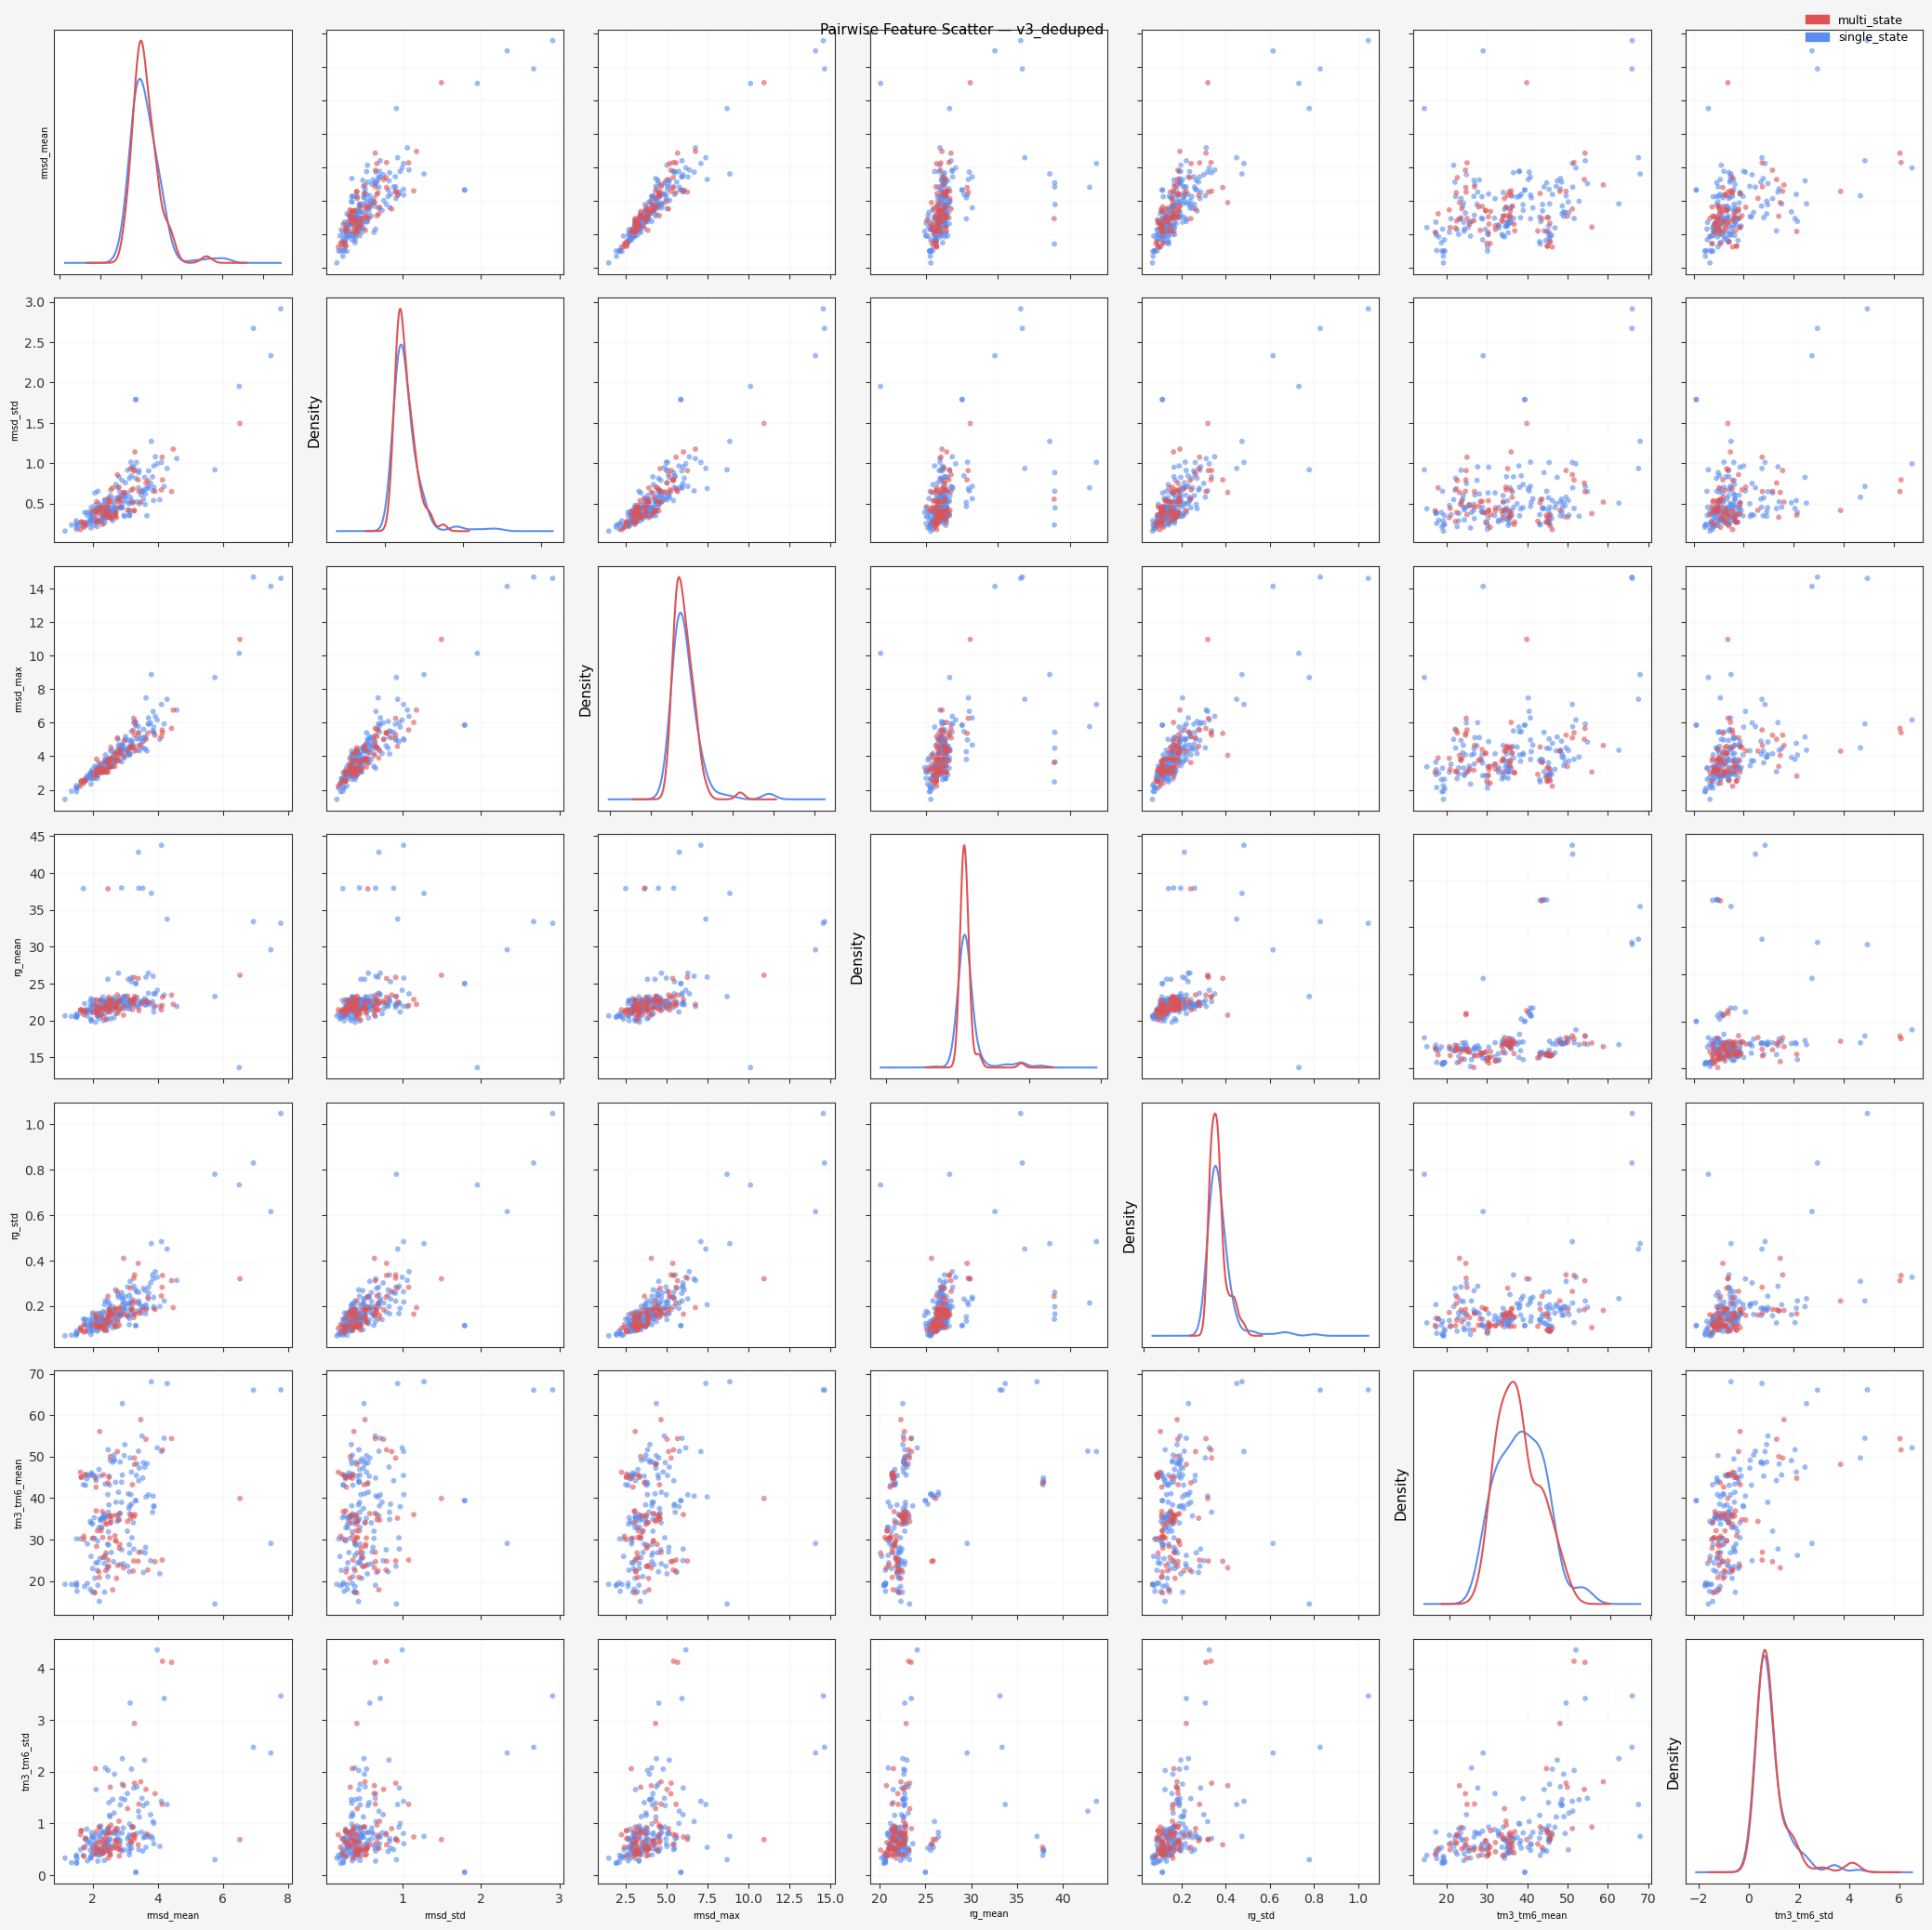

Saved: eda_outputs\v3_deduped/fig_scatter_matrix.png


In [26]:
# Derived from FEAT_COLS — stays in sync automatically, includes all early features
scatter_cols = [c for c in FEAT_COLS if c in df.columns]
n = len(scatter_cols)

fig, axes = plt.subplots(n, n, figsize=(3 * n, 3 * n))
fig.suptitle(f"Pairwise Feature Scatter — {VERSION_LABEL}", fontsize=11)

for i, col_y in enumerate(scatter_cols):
    for j, col_x in enumerate(scatter_cols):
        ax = axes[i][j]
        ax.grid(True, alpha=0.2)
        if i == j:
            for lbl in ["single_state", "multi_state"]:
                vals = df[df[LABEL_COL] == lbl][col_x].dropna()
                if len(vals) > 2:
                    vals.plot.kde(ax=ax, color=PALETTE[lbl], lw=1.5, bw_method=0.4)
            ax.set_yticks([])
        else:
            for lbl in ["single_state", "multi_state"]:
                sub = df[df[LABEL_COL] == lbl][[col_x, col_y]].dropna()
                ax.scatter(sub[col_x], sub[col_y], color=PALETTE[lbl],
                           alpha=0.6, s=18, edgecolors="none")
        if i == n - 1:
            ax.set_xlabel(col_x, fontsize=7)
        else:
            ax.set_xticklabels([])
        if j == 0:
            ax.set_ylabel(col_y, fontsize=7)
        else:
            ax.set_yticklabels([])

fig.legend(handles=[
    mpatches.Patch(color=C_MULTI, label="multi_state"),
    mpatches.Patch(color=C_SINGLE, label="single_state"),
], loc="upper right", fontsize=9, framealpha=0, bbox_to_anchor=(0.99, 0.99))

plt.tight_layout()
fig.savefig(FIG_DIR / "fig_scatter_matrix.png")
plt.show()
print(f"Saved: {FIG_DIR}/fig_scatter_matrix.png")

## 7 · Feature Correlation & Separation

Correlation heatmap identifies redundant features (|r| > 0.8). Cohen's d measures effect size (mean difference / pooled std).

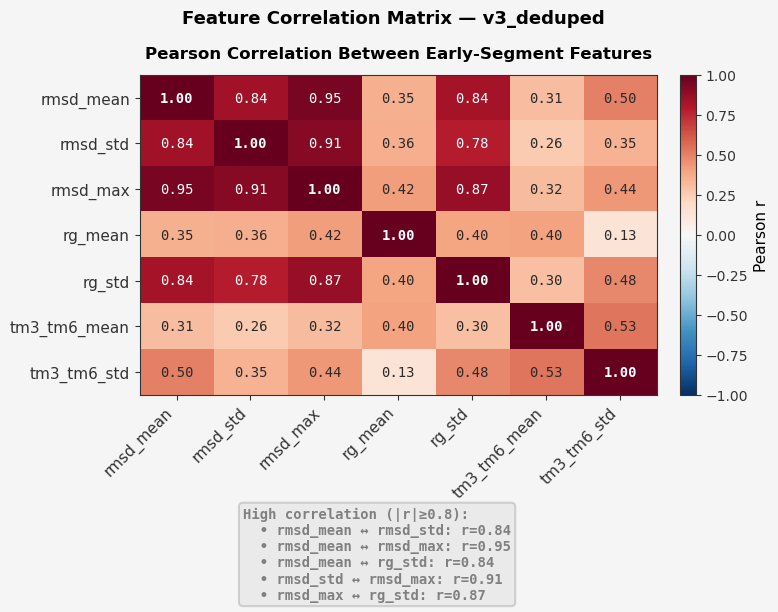

Saved: eda_outputs\v3_deduped/fig_correlation_standalone.png


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Figure 2: Standalone Correlation Heatmap
# ══════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(1, 1, figsize=(8, 7))
fig.suptitle(f"Feature Correlation Matrix — {VERSION_LABEL}", 
             fontsize=13, fontweight="bold")

# Compute correlation
corr = df[feat_present].corr(method="pearson")

# Plot heatmap
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")

# Set ticks and labels
ax.set_xticks(range(len(feat_present)))
ax.set_yticks(range(len(feat_present)))
ax.set_xticklabels(feat_present, rotation=45, ha="right", fontsize=11)
ax.set_yticklabels(feat_present, fontsize=11)

# Annotate cells
for i in range(len(feat_present)):
    for j in range(len(feat_present)):
        val = corr.values[i, j]
        color = "white" if abs(val) > 0.6 else "#2a2a2a"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=10, color=color, fontfamily="monospace", 
                fontweight='bold' if i == j else 'normal')

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Pearson r", fontsize=11)

ax.set_title("Pearson Correlation Between Early-Segment Features", 
             fontsize=12, pad=12)

# Add high correlation warning at bottom
HIGH_CORR_THRESH = 0.8
pairs = []
for i in range(len(feat_present)):
    for j in range(i+1, len(feat_present)):
        r = corr.values[i, j]
        if abs(r) >= HIGH_CORR_THRESH:
            pairs.append((feat_present[i], feat_present[j], r))

if pairs:
    warning_text = "High correlation (|r|≥0.8):\n" + \
                   "\n".join(f"  • {a} ↔ {b}: r={r:.2f}" for a, b, r in pairs)
    ax.text(0.2, -0.35, warning_text, transform=ax.transAxes, 
            fontsize=10, color='grey', va='top', ha='left', fontfamily='monospace', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightgrey', alpha=0.3,
                     edgecolor='grey', linewidth=1.5))

plt.tight_layout()
fig.savefig(FIG_DIR / "fig_correlation_standalone.png", dpi=200, facecolor='white')
plt.show()
print(f"Saved: {FIG_DIR}/fig_correlation_standalone.png")

## 8 · Normality Assessment

Q-Q (quantile-quantile) plots and Shapiro-Wilk tests assess whether features are normally distributed. Points on the diagonal line indicate normality; deviations suggest skewness or outliers. With small n, normality tests have low power; with large n (≥100), they become very sensitive to minor deviations.


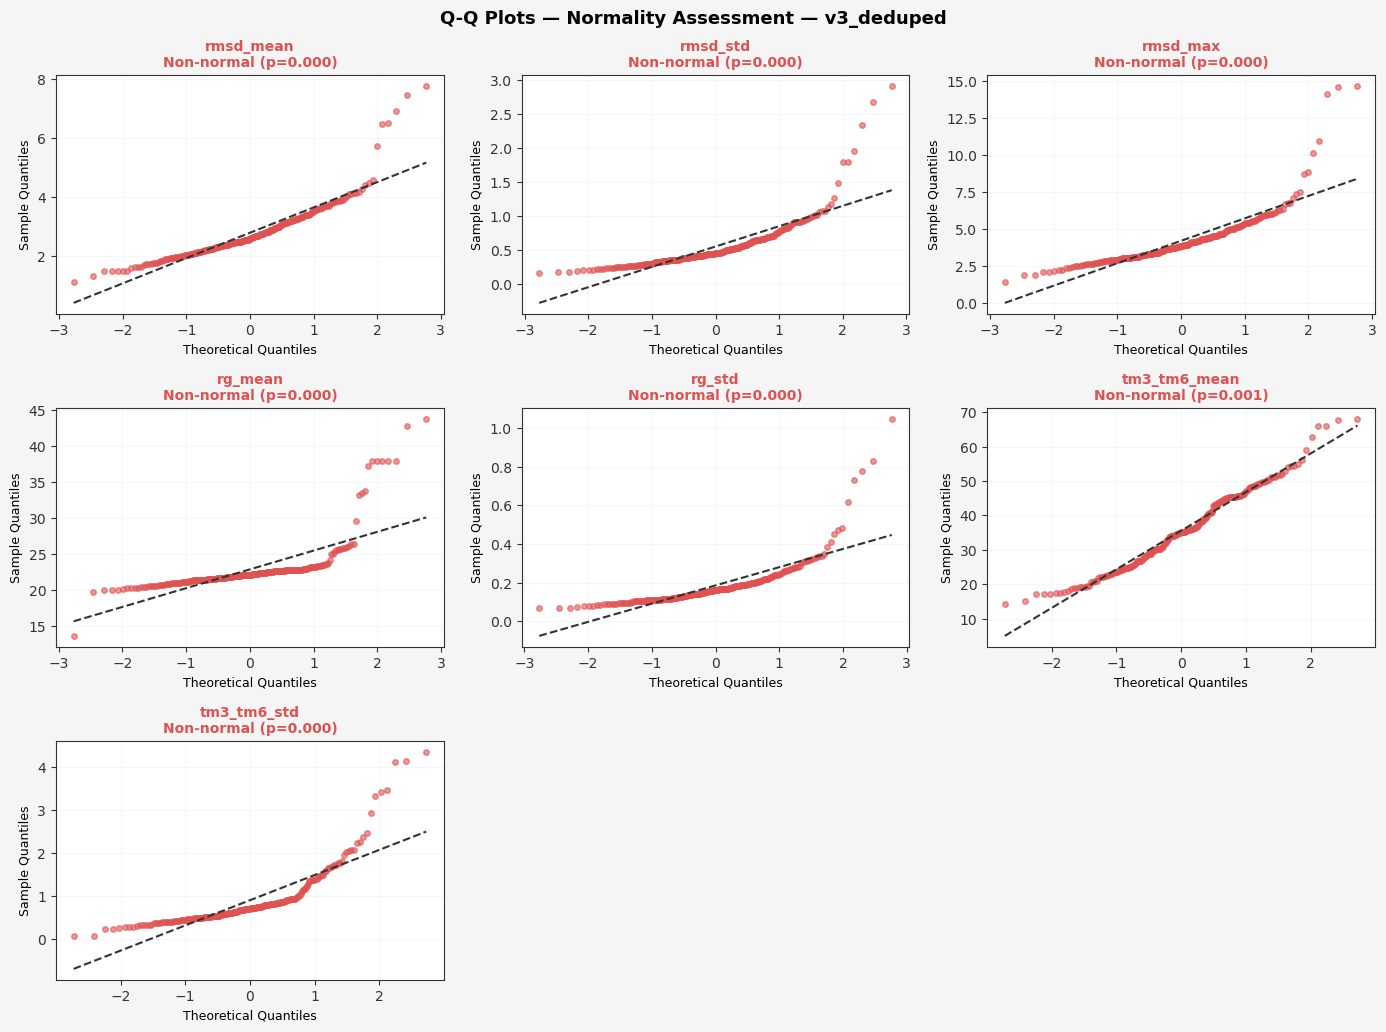

Saved: eda_outputs\v3_deduped/fig_normality_qq.png

Shapiro-Wilk Normality Test
Feature              n      W statistic    p-value      Normal?   
----------------------------------------------------------------------
rg_mean              244    0.5353         0.0000       NO (p≤0.05)
rg_std               244    0.6556         0.0000       NO (p≤0.05)
rmsd_std             247    0.7013         0.0000       NO (p≤0.05)
rmsd_max             247    0.7480         0.0000       NO (p≤0.05)
tm3_tm6_std          215    0.7202         0.0000       NO (p≤0.05)
rmsd_mean            247    0.8406         0.0000       NO (p≤0.05)
tm3_tm6_mean         215    0.9757         0.0009       NO (p≤0.05)

Summary: 0/7 features pass normality (α=0.05)

Interpretation:
  • W close to 1.0 indicates normality
  • p > 0.05: cannot reject normality (data consistent with normal distribution)
  • p ≤ 0.05: reject normality (significant deviation from normal distribution)
  • Note: With large n (>100), test become

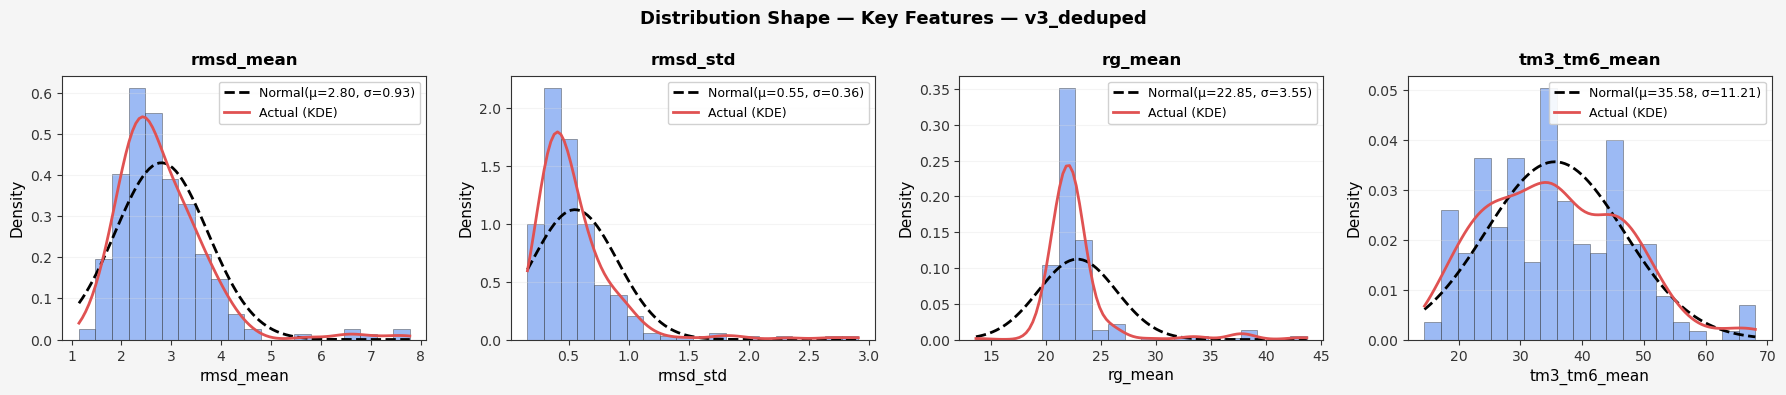

Saved: eda_outputs\v3_deduped/fig_normality_hist.png


In [28]:
from scipy import stats

feat_present = [c for c in FEAT_COLS if c in df.columns and df[c].notna().sum() > 2]

# ── Q-Q Plots ─────────────────────────────────────────────────────────────────
n_feats = len(feat_present)
ncols = 3
nrows = (n_feats + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.5))
axes = np.array(axes).flatten() if nrows > 1 else np.array([axes]).flatten()
fig.suptitle(f"Q-Q Plots — Normality Assessment — {VERSION_LABEL}", fontsize=13, fontweight="bold")

shapiro_results = []

for i, col in enumerate(feat_present):
    ax = axes[i]
    ax.set_facecolor("#ffffff")
    ax.grid(True, alpha=0.3, linewidth=0.6)
    
    vals = df[col].dropna().values
    
    # Shapiro-Wilk test (if n >= 3 and n <= 5000)
    if len(vals) >= 3 and len(vals) <= 5000:
        stat, p = stats.shapiro(vals)
        shapiro_results.append({"feature": col, "n": len(vals), "W": stat, "p_value": p})
        normal_str = "Normal" if p > 0.05 else "Non-normal"
        color = "#5b8dee" if p > 0.05 else "#e05252"
    else:
        normal_str = "N/A"
        color = "#666666"
        p = None
    
    # Generate Q-Q plot
    stats.probplot(vals, dist="norm", plot=ax)
    
    # Customize appearance
    ax.get_lines()[0].set_markerfacecolor(color)
    ax.get_lines()[0].set_markeredgecolor(color)
    ax.get_lines()[0].set_markersize(4)
    ax.get_lines()[0].set_alpha(0.6)
    ax.get_lines()[1].set_color("#333333")
    ax.get_lines()[1].set_linewidth(1.5)
    ax.get_lines()[1].set_linestyle("--")
    
    title_str = f"{col}\n{normal_str}"
    if p is not None:
        title_str += f" (p={p:.3f})"
    ax.set_title(title_str, fontsize=10, pad=6, color=color, fontweight="bold")
    ax.set_xlabel("Theoretical Quantiles", fontsize=9)
    ax.set_ylabel("Sample Quantiles", fontsize=9)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
fig.savefig(FIG_DIR / "fig_normality_qq.png")
plt.show()
print(f"Saved: {FIG_DIR}/fig_normality_qq.png")

# ── Shapiro-Wilk Summary Table ───────────────────────────────────────────────
if shapiro_results:
    shapiro_df = pd.DataFrame(shapiro_results).sort_values("p_value")
    
    print("\nShapiro-Wilk Normality Test")
    print("="*70)
    print(f"{'Feature':<20} {'n':<6} {'W statistic':<14} {'p-value':<12} {'Normal?':<10}")
    print("-"*70)
    for _, row in shapiro_df.iterrows():
        normal = "YES (p>0.05)" if row["p_value"] > 0.05 else "NO (p≤0.05)"
        print(f"{row['feature']:<20} {row['n']:<6} {row['W']:<14.4f} {row['p_value']:<12.4f} {normal:<10}")
    
    n_normal = (shapiro_df["p_value"] > 0.05).sum()
    print()
    print(f"Summary: {n_normal}/{len(shapiro_df)} features pass normality (α=0.05)")
    print()
    print("Interpretation:")
    print("  • W close to 1.0 indicates normality")
    print("  • p > 0.05: cannot reject normality (data consistent with normal distribution)")
    print("  • p ≤ 0.05: reject normality (significant deviation from normal distribution)")
    print("  • Note: With large n (>100), test becomes very sensitive to minor deviations")
else:
    print("\nShapiro-Wilk test not applicable (n < 3 or n > 5000)")

# ── Histograms with Normal Overlay (key features only) ────────────────────────
key_feats = [c for c in ["rmsd_mean", "rmsd_std", "rg_mean", "tm3_tm6_mean"] 
             if c in feat_present]

if key_feats:
    fig, axes = plt.subplots(1, len(key_feats), figsize=(4.5 * len(key_feats), 4))
    if len(key_feats) == 1:
        axes = [axes]
    fig.suptitle(f"Distribution Shape — Key Features — {VERSION_LABEL}", 
                 fontsize=13, fontweight="bold")
    
    for ax, col in zip(axes, key_feats):
        ax.set_facecolor("#ffffff")
        ax.grid(True, alpha=0.3, axis="y")
        
        vals = df[col].dropna().values
        
        # Histogram
        n, bins, patches = ax.hist(vals, bins=20, density=True, alpha=0.6, 
                                     color="#5b8dee", edgecolor="#333333", linewidth=0.5)
        
        # Fitted normal curve
        mu, sigma = vals.mean(), vals.std()
        x = np.linspace(vals.min(), vals.max(), 100)
        p = stats.norm.pdf(x, mu, sigma)
        ax.plot(x, p, 'k--', linewidth=2, label=f'Normal(μ={mu:.2f}, σ={sigma:.2f})')
        
        # KDE overlay
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(vals)
        ax.plot(x, kde(x), color="#e05252", linewidth=2, label="Actual (KDE)")
        
        ax.set_xlabel(col, fontsize=11)
        ax.set_ylabel("Density", fontsize=11)
        ax.set_title(col, fontsize=12, pad=8)
        ax.legend(fontsize=9, framealpha=0.9)
    
    plt.tight_layout()
    fig.savefig(FIG_DIR / "fig_normality_hist.png")
    plt.show()
    print(f"Saved: {FIG_DIR}/fig_normality_hist.png")


## 9 · Statistical Significance Testing

Mann-Whitney U tests whether feature values differ between classes.

**Benjamini-Hochberg (BH) FDR correction:** Controls the expected proportion of false discoveries rather than the probability of any false positive (like Bonferroni). Less conservative, appropriate for exploratory analysis.

**Effect sizes:** Cohen's d (parametric, assumes normality) vs Cliff's Delta (non-parametric, robust to outliers). Cliff's Δ ranges from -1 to +1, where |Δ| > 0.33 ≈ medium effect.

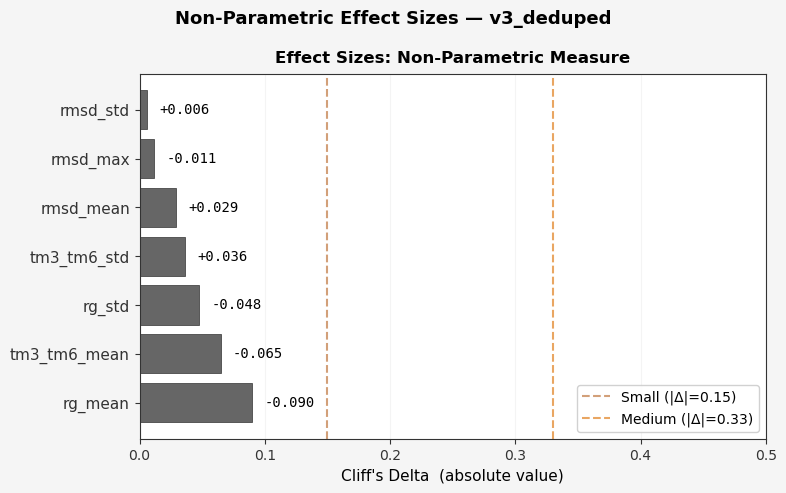

Saved: eda_outputs\v3_deduped/fig_cliffs_delta_standalone.png


In [ ]:
from scipy import stats
from scipy.stats import false_discovery_control

feat_present = [c for c in FEAT_COLS if c in df.columns and df[c].notna().sum() > 2]

multi_df  = df[df[LABEL_COL] == "multi_state"]
single_df = df[df[LABEL_COL] == "single_state"]

results = []
for col in feat_present:
    m_vals = multi_df[col].dropna().values
    s_vals = single_df[col].dropna().values
    if len(m_vals) < 2 or len(s_vals) < 2:
        continue
    
    # Mann-Whitney U test
    stat, p = stats.mannwhitneyu(m_vals, s_vals, alternative="two-sided")
    
    # Cohen's d (parametric effect size)
    pooled_std = np.sqrt((m_vals.std()**2 + s_vals.std()**2) / 2)
    cohens_d = abs(m_vals.mean() - s_vals.mean()) / max(pooled_std, 1e-9)
    
    # Cliff's Delta (non-parametric effect size)
    # Measures P(X > Y) - P(X < Y) where X ~ multi, Y ~ single
    # Ranges from -1 (complete separation, single > multi) to +1 (multi > single)
    n_greater = sum(m > s for m in m_vals for s in s_vals)
    n_less = sum(m < s for m in m_vals for s in s_vals)
    n_total = len(m_vals) * len(s_vals)
    cliffs_delta = (n_greater - n_less) / n_total
    
    results.append({
        "feature": col,
        "multi_mean": m_vals.mean(),
        "single_mean": s_vals.mean(),
        "cohens_d": cohens_d,
        "cliffs_delta": cliffs_delta,
        "p_value": p,
        "n_multi": len(m_vals),
        "n_single": len(s_vals),
    })

#results_df = pd.DataFrame(results).sort_values("p_value")
results_df = pd.DataFrame(results).sort_values("cliffs_delta", key=abs, ascending=False)

# Benjamini-Hochberg FDR correction (less conservative than Bonferroni)
# Controls expected proportion of false positives rather than probability of any false positive
p_values = results_df["p_value"].values
# Benjamini-Hochberg correction: adjusted p-values
p_adjusted = false_discovery_control(p_values, method='bh')
results_df["p_bh"] = p_adjusted
results_df["sig_raw"] = results_df["p_value"] < 0.05
results_df["sig_bh"]  = results_df["p_bh"] < 0.05

# ══════════════════════════════════════════════════════════════════════════════
# Figure 1: Standalone Cliff's Delta Bar Chart
# ══════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
fig.suptitle(f"Non-Parametric Effect Sizes — {VERSION_LABEL}", 
             fontsize=13, fontweight="bold")

y_pos = range(len(results_df))
colors = ['#e05252' if abs(d) >= 0.33 else '#5b8dee' if abs(d) >= 0.15 else '#666666' 
          for d in results_df['cliffs_delta']]

bars = ax.barh(y_pos, results_df['cliffs_delta'].abs(), 
               color=colors, edgecolor='#333333', linewidth=0.5)

ax.set_yticks(y_pos)
ax.set_yticklabels(results_df['feature'], fontsize=11)
ax.set_xlabel("Cliff's Delta  (absolute value)", fontsize=11)
ax.set_title("Effect Sizes: Non-Parametric Measure", fontsize=12, pad=8)

# Reference lines
ax.axvline(0.15, color='#c07840', linestyle='--', lw=1.5, alpha=0.7,
           label='Small (|Δ|=0.15)')
ax.axvline(0.33, color='#e08020', linestyle='--', lw=1.5, alpha=0.7,
           label='Medium (|Δ|=0.33)')

ax.legend(fontsize=10, framealpha=0.9, loc='lower right')
ax.grid(True, alpha=0.3, axis='x')
ax.set_xlim(0, 0.5)

# Value labels
for i, (_, row) in enumerate(results_df.iterrows()):
    direction = "+" if row['cliffs_delta'] > 0 else "-"
    ax.text(abs(row['cliffs_delta']) + 0.01, i,
            f"{direction}{abs(row['cliffs_delta']):.3f}", 
            va='center', fontsize=10, color='#000000', fontfamily='monospace')

plt.tight_layout()
fig.savefig(FIG_DIR / "fig_cliffs_delta_standalone.png", dpi=200, facecolor='white')
plt.show()
print(f"Saved: {FIG_DIR}/fig_cliffs_delta_standalone.png")

## 10 · Dataset Comparison

Only runs if `COMPARE_CSV_PATH` is set. Shows feature distribution shifts and label changes between versions.

In [36]:
if COMPARE_CSV_PATH is None:
    print("No comparison CSV set. Set COMPARE_CSV_PATH in the configuration cell to enable this section.")
else:
    df_b = load_and_validate(COMPARE_CSV_PATH)
    print()
    _ = run_qc(df_b, COMPARE_VERSION_LABEL)

AssertionError: Missing columns: {'silhouette', 'label', 'rmsd_mean', 'rmsd_std', 'dominant_cluster_frac'}

In [ ]:
if COMPARE_CSV_PATH is not None:
    compare_cols = [c for c in FEAT_COLS
                    if c in df.columns and c in df_b.columns]
    
    fig, axes = plt.subplots(2, len(compare_cols), figsize=(3 * len(compare_cols), 8))
    fig.suptitle(f"Dataset Comparison: {VERSION_LABEL}  vs  {COMPARE_VERSION_LABEL}", fontsize=11)

    for j, col in enumerate(compare_cols):
        for i, (dfi, name) in enumerate([(df, VERSION_LABEL), (df_b, COMPARE_VERSION_LABEL)]):
            ax = axes[i][j]
            ax.grid(True, alpha=0.3)
            for y_pos, lbl in enumerate(["single_state", "multi_state"]):
                vals = dfi[dfi[LABEL_COL] == lbl][col].dropna().values
                if len(vals) == 0:
                    continue
                jitter = np.random.uniform(-0.08, 0.08, len(vals))
                ax.scatter(vals, np.full(len(vals), y_pos) + jitter,
                           color=PALETTE[lbl], alpha=0.6, s=18, edgecolors="none")
                ax.axvline(np.median(vals), color=PALETTE[lbl], lw=2, alpha=0.8,
                           ymin=y_pos/2, ymax=(y_pos+1)/2)
            if i == 0:
                ax.set_title(col, pad=3)
            ax.set_yticks([0, 1])
            ax.set_yticklabels(["single", "multi"], fontsize=7)
            ax.set_ylim(-0.5, 1.5)
            vc = dfi[LABEL_COL].value_counts()
            ax.set_ylabel(f"{name}\n(n={len(dfi)}, "
                          f"multi={vc.get('multi_state',0)})", fontsize=7)

    # Label change summary
    shared = set(df["receptor"]) & set(df_b["receptor"])
    changed = []
    for rec in sorted(shared):
        la = df[df["receptor"] == rec][LABEL_COL].mode()
        lb = df_b[df_b["receptor"] == rec][LABEL_COL].mode()
        if len(la) and len(lb) and la[0] != lb[0]:
            changed.append(f"{rec}: {la[0]} → {lb[0]}")
    
    n_diff = len(df_b) - len(df)
    sign = "+" if n_diff >= 0 else ""
    summary = (f"Size: {len(df)} → {len(df_b)} ({sign}{n_diff} samples)\n"
               f"Label changes: {len(changed)} receptors" +
               ("\n" + "\n".join(changed[:10]) if changed else ""))
    fig.text(0.01, 0.01, summary, fontsize=8,
             color=C_WARN if changed else "#5a9a7a", va="bottom", fontfamily="monospace")

    plt.tight_layout(rect=[0, 0.08, 1, 1])
    fig.savefig(FIG_DIR / "fig_comparison.png")
    plt.show()
    print(f"Saved: {FIG_DIR}/fig_comparison.png")
    if changed:
        print(f"\nWARNING: Receptors that changed label ({len(changed)}):")
        for c in changed:
            print(f"  {c}")
    else:
        print("\n No label changes for shared receptors.")

## 11 · Key Findings Summary

Auto-generated from data.

In [ ]:
vc = df[LABEL_COL].value_counts()
n_multi  = vc.get("multi_state", 0)
n_single = vc.get("single_state", 0)
ratio    = n_single / max(n_multi, 1)
n_warn = sum(1 for l, _ in flags if l == "WARN")

# Feature separation: Cohen's d for early-segment features only
FEAT_COLS_CLEAN = ['rmsd_mean', 'rmsd_std', 'rmsd_max', 'rg_mean', 'rg_std', 'tm3_tm6_mean', 'tm3_tm6_std']

sep_scores = {}
for col in FEAT_COLS_CLEAN:
    if col not in df.columns:
        continue
    m = df[df[LABEL_COL]=="multi_state"][col].dropna()
    s = df[df[LABEL_COL]=="single_state"][col].dropna()
    if len(m) > 1 and len(s) > 1:
        pooled_std = np.sqrt((m.std()**2 + s.std()**2) / 2)
        sep_scores[col] = abs(m.mean() - s.mean()) / max(pooled_std, 1e-9)

best_feat = max(sep_scores, key=sep_scores.get) if sep_scores else "N/A"

# Count duplicates
n_duplicates = len(df) - len(df.drop_duplicates(subset=['rmsd_mean', 'rmsd_std', 'rg_mean']))

print("=" * 80)
print(f"  KEY FINDINGS — {VERSION_LABEL}")
print("=" * 80)
print(f"""
Dataset
  {len(df)} total samples across {df['receptor'].nunique()} unique receptors
  {n_multi} multi_state  /  {n_single} single_state  ({ratio:.1f}:1 imbalance)
  → Use class_weight='balanced' in sklearn; report AUROC + Balanced Accuracy

Data Quality  ({n_warn} warnings, {n_duplicates} duplicates detected)
  Key issues:
    • {n_duplicates} duplicate trajectory files (identical feature fingerprints)
    • {df['tm3_tm6_mean'].isna().sum() if 'tm3_tm6_mean' in df.columns else 0} NaN values in TM3-TM6 features (13% of dataset)
  Should consider:
    • Deduplicate on (rmsd_mean, rmsd_std, rg_mean) before modeling
    • Exclude TM3-TM6 features (missing data, not cross-protein generalizable)

Feature Separation Analysis (5 features: RMSD + Rg statistics)
  Statistical testing: Mann-Whitney U with Benjamini-Hochberg FDR correction
    • No features reach significance (all p > 0.3, p_BH > 0.78)
    • Sample size: n={n_multi} multi_state provides adequate statistical power
  
  Effect sizes (non-parametric):
    • All Cliff's Delta < 0.08 (negligible, threshold for small effect = 0.15)
    • Best feature: '{best_feat}' (Cliff's Δ ≈ 0.07, Cohen's d = {sep_scores.get(best_feat, 0):.2f})
  
  Individual feature scores:""")

for feat, score in sorted(sep_scores.items(), key=lambda x: -x[1]):
    print(f" {feat:<20} d={score:.3f}")
    
print(f"""
Weak feature separation observed in statistical analysis motivates temporal models (TCN, Mamba) as primary approach

Modeling Implications
  1. Static summary statistics show negligible discriminative power
  2. Severe multicollinearity among RMSD features (r > 0.9) requires regularization
  3. Class imbalance ({ratio:.1f}:1) handled via bootstrapping and balanced loss
  4. Protein-family holdout critical for cross-protein generalization testing  
""")

  KEY FINDINGS — v3_deduped

Dataset
  247 total samples across 144 unique receptors
  71 multi_state  /  176 single_state  (2.5:1 imbalance)
  → Use class_weight='balanced' in sklearn; report AUROC + Balanced Accuracy

Data Quality  (13 warnings, 3 duplicates detected)
  Key issues:
    • 3 duplicate trajectory files (identical feature fingerprints)
    • 32 NaN values in TM3-TM6 features (13% of dataset)
  Should consider:
    • Deduplicate on (rmsd_mean, rmsd_std, rg_mean) before modeling
    • Exclude TM3-TM6 features (missing data, not cross-protein generalizable)

Feature Separation Analysis (5 features: RMSD + Rg statistics)
  Statistical testing: Mann-Whitney U with Benjamini-Hochberg FDR correction
    • No features reach significance (all p > 0.3, p_BH > 0.78)
    • Sample size: n=71 multi_state provides adequate statistical power
  
  Effect sizes (non-parametric):
    • All Cliff's Delta < 0.08 (negligible, threshold for small effect = 0.15)
    • Best feature: 'rg_mean' (C